In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
class ForestPatchDataset(Dataset):

    def __init__(self, root):

        self.t1_dir = os.path.join(root, "t1")
        self.t2_dir = os.path.join(root, "t2")
        self.label_dir = os.path.join(root, "label")

        self.files = sorted(os.listdir(self.t1_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        name = self.files[idx]

        t1 = np.load(os.path.join(self.t1_dir, name), mmap_mode="r")
        t2 = np.load(os.path.join(self.t2_dir, name), mmap_mode="r")
        label = np.load(os.path.join(self.label_dir, name), mmap_mode="r")

        t1 = torch.from_numpy(t1).float()
        t2 = torch.from_numpy(t2).float()
        label = torch.from_numpy(label).unsqueeze(0).float()

        t1 = torch.nan_to_num(t1, nan=0.0)
        t2 = torch.nan_to_num(t2, nan=0.0)
        label = torch.nan_to_num(label, nan=0.0)

        return t1, t2, label

In [4]:
data_dir = "/kaggle/input/datasets/suranjandas1990/forest-loss-dataset/dataset/Nagaland_2021_2023"

dataset = ForestPatchDataset(data_dir)

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

print("Total tiles:", len(dataset))

Total tiles: 2431


In [5]:
# -----------------------------
# Helper Functions
# -----------------------------

def stretch(img, pmin=2, pmax=98):
    lo = np.percentile(img, pmin)
    hi = np.percentile(img, pmax)
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

def normalize_s1(x, vmin=-25, vmax=0):
    x = np.clip(x, vmin, vmax)
    return (x - vmin) / (vmax - vmin)

def sar_composite(vv, vh):
    ratio = vv - vh   # already in dB
    return np.stack([
        normalize_s1(vv),
        normalize_s1(vh),
        normalize_s1(ratio, -10, 10)
    ], axis=-1)

# -----------------------------
# Visualization
# -----------------------------

import random

def visualize_samples(dataset, n=4):

    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(n*2, 4, figsize=(16, 4*n*2))

    for i, idx in enumerate(indices):

        t1, t2, mask = dataset[idx]

        t1 = t1.numpy()
        t2 = t2.numpy()
        mask = mask.squeeze().numpy()

        row1 = 2*i
        row2 = 2*i + 1

        # ----- TIME 1 -----
        rgb1 = stretch(np.stack([t1[2], t1[1], t1[0]], axis=-1))
        nir1 = stretch(t1[3])
        sar1 = normalize_s1((t1[4] + t1[5]) / 2)

        axes[row1,0].imshow(rgb1)
        axes[row1,0].set_title("T1 RGB")
        axes[row1,0].axis("off")

        axes[row1,1].imshow(nir1, cmap="gray")
        axes[row1,1].set_title("T1 NIR")
        axes[row1,1].axis("off")

        axes[row1,2].imshow(sar1, cmap="gray")
        axes[row1,2].set_title("T1 SAR")
        axes[row1,2].axis("off")

        axes[row1,3].imshow(mask, cmap="gray")
        axes[row1,3].set_title("Mask")
        axes[row1,3].axis("off")

        # ----- TIME 2 -----
        rgb2 = stretch(np.stack([t2[2], t2[1], t2[0]], axis=-1))
        nir2 = stretch(t2[3])
        sar2 = normalize_s1((t2[4] + t2[5]) / 2)

        axes[row2,0].imshow(rgb2)
        axes[row2,0].set_title("T2 RGB")
        axes[row2,0].axis("off")

        axes[row2,1].imshow(nir2, cmap="gray")
        axes[row2,1].set_title("T2 NIR")
        axes[row2,1].axis("off")

        axes[row2,2].imshow(sar2, cmap="gray")
        axes[row2,2].set_title("T2 SAR")
        axes[row2,2].axis("off")

        axes[row2,3].imshow(mask, cmap="gray")
        axes[row2,3].set_title("Mask")
        axes[row2,3].axis("off")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_17/677382648.py:22: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:206.)
  t1 = torch.from_numpy(t1).float()


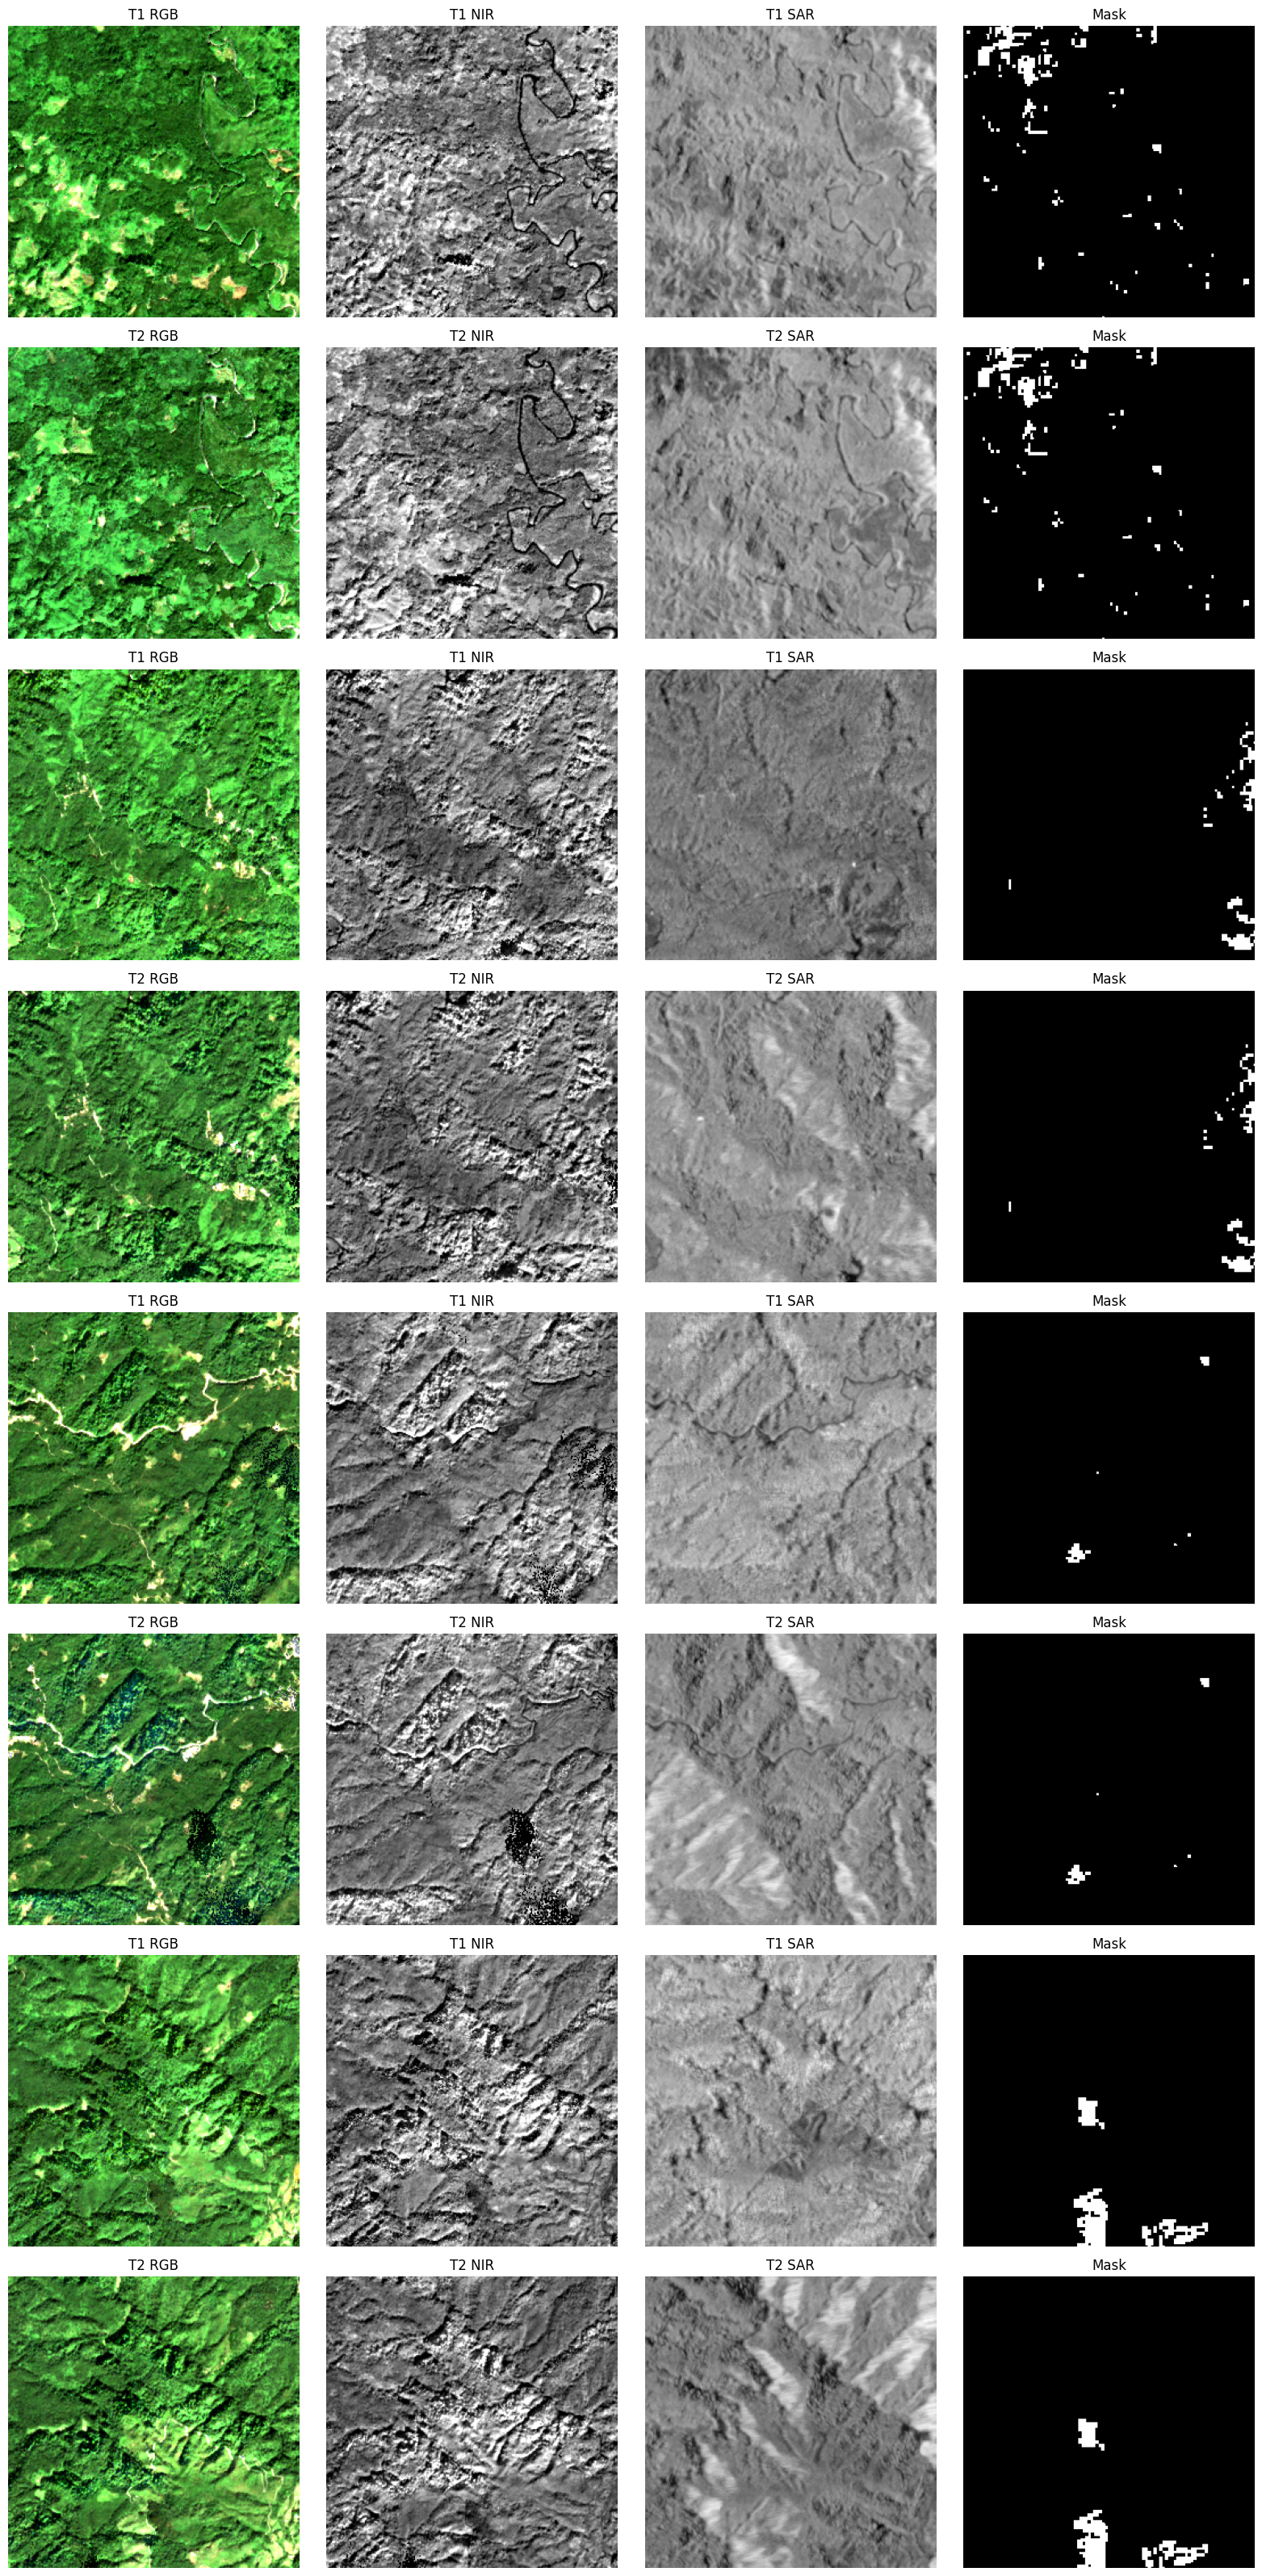

In [6]:
# first row represents 1st year ans 2nd row represents 2nd and so on
visualize_samples(dataset, n=4);

In [7]:
def plot_change_distribution(label_dir):

    files = sorted(os.listdir(label_dir))

    change_pixels = []

    for f in tqdm(files):

        label = np.load(os.path.join(label_dir, f), mmap_mode="r")

        count = np.sum(label > 0)
        change_pixels.append(count)

    change_pixels = np.array(change_pixels)

    print("Total patches:", len(change_pixels))
    print("Mean change pixels:", change_pixels.mean())
    print("Median change pixels:", np.median(change_pixels))
    print("Max change pixels:", change_pixels.max())

    plt.figure(figsize=(8,5))
    plt.hist(change_pixels, bins=50)
    plt.xlabel("Number of Change Pixels")
    plt.ylabel("Number of Patches")
    plt.title("Distribution of Change Pixels per Patch")
    plt.show()

100%|██████████| 2431/2431 [00:25<00:00, 96.60it/s] 


Total patches: 2431
Mean change pixels: 826.4290415466886
Median change pixels: 364.0
Max change pixels: 13619


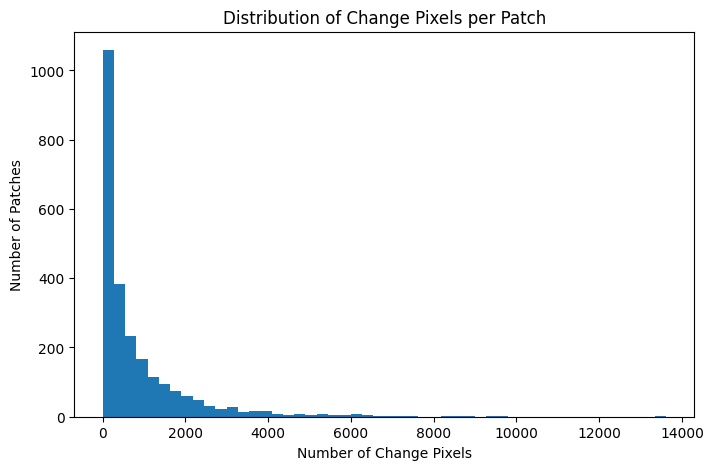

In [8]:
plot_change_distribution(f"{data_dir}/label")